In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
PLOT_DPI = 100
SEED = 42

# DATA_FILE = "../data/preprocessed_skab_dataset.csv"
# SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_fe.csv"

# DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote.csv"
# SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"

# DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn.csv"
# SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"

# DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan.csv"
# SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_fe.csv"

DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1.csv"
SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1_fe.csv"

PLOT_PAIR_PLOT = False
SAVE_INDEX = False

In [3]:
dataframe = pd.read_csv(DATA_FILE)

if "datetime" in dataframe.columns:
    dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
    dataframe.drop(columns=["datetime"], inplace=True)
    
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,No Anomaly,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,No Anomaly,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,No Anomaly,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,No Anomaly,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,No Anomaly,0.0


In [4]:
dataframe_anomaly = dataframe[["anomaly", "description"]]
dataframe.drop(columns=["anomaly", "description"], inplace=True)

## Helper Functions

In [5]:
def plot_pairplot(df, columns, title=None):
    """
    Plots a pairplot of the given dataframe with specified columns and hue.
    
    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
    """
    plt.figure(figsize=(12, 12), dpi=PLOT_DPI)
    ax = sns.pairplot(
                        data = df, 
                        hue="description", 
                        hue_order=df["description"].value_counts().index, 
                        vars=columns, 
                        corner=True, 
                        plot_kws={'edgecolor': 'black', 'alpha': 0.6},
                        markers=['P', 'X', 'o', 'v', '^', '<', '>', 'h', 'H', 'D', 'd', 's', 'p', '8'],
    )
    sns.move_legend(ax, "center right", ncol=1, title="description", frameon=True)
    ax.fig.suptitle(title, y=1.02, weight="bold", fontsize=30) # Adjust y for vertical positioning

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    # plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/engineered_features/{title}.png", format="png")
    plt.show()

## Interaction Features (Products/Ratios)

### Power (Watt)

**Voltage \* Current = Power:** Electrical power is a fundamental operational parameter. Anomalies might manifest as unusual power consumption.

In [6]:
dataframe["Power"] = dataframe["Voltage"] * dataframe["Current"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440


### Electrical Resistence

**Pressure / Flow Rate (or Resistance analog):** A high pressure with low flow rate, or vice-versa, could indicate a blockage, leak, or pump inefficiency.

In [7]:
dataframe["Electrical_Resistence"] = dataframe["Voltage"] / dataframe["Current"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738


### Pressure / Flow Rate (or Resistance analog)

**Pressure / Flow Rate (or Resistance analog):** A high pressure with low flow rate, or vice-versa, could indicate a blockage, leak, or pump inefficiency.

In [8]:
dataframe["Flow_Resistance"] = dataframe["Pressure"] / (dataframe["Volume Flow RateRMS"]  + 1e-6)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526


### Temperature (Engine) / Temperature (Fluid)

**Temperature (Engine) / Temperature (Fluid):** A large difference or sudden change could point to cooling system issues or excessive internal friction.

In [9]:
dataframe["Temperature_EbyF"] = dataframe["Temperature"] / dataframe["Thermocouple"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159


### Accelerometer1RMS \* Accelerometer2RMS

**Accelerometer1RMS \* Accelerometer2RMS:** Product of two vibration sensors might amplify certain fault signatures.

In [10]:
dataframe["AccelerometerRMS"] = dataframe["Accelerometer1RMS"] * dataframe["Accelerometer2RMS"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557


### Specific Power (Power / Flow Rate)

**Specific Power (Power / Flow Rate):** Energy consumption per unit of fluid moved.

In [11]:
dataframe["Specific_Power"] = dataframe["Power"] / dataframe["Volume Flow RateRMS"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123


## Difference Features

### Difference in AccelerometerRMS

**Accelerometer1RMS - Accelerometer2RMS:** Difference in vibration readings across two points could indicate uneven wear or alignment issues.

In [12]:
dataframe["Accelerometer_Balance"] = dataframe["Accelerometer2RMS"] - dataframe["Accelerometer1RMS"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180,0.047463
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941,0.013899
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509,0.045516
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454,0.039008
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123,0.047607


### Temperature Difference in Engine & Fluid

**Temperature (Engine) - Temperature (Fluid):** Direct temperature differential.

In [13]:
dataframe["Temperature_Difference"] = dataframe["Temperature"] - dataframe["Thermocouple"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180,0.047463,59.9847
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941,0.013899,43.8822
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509,0.045516,58.5997
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454,0.039008,57.3947
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123,0.047607,65.1049


## Efficiency & Performance Metrics

### Hydraulic Power

1.  **Hydraulic Power:**
    * **Formula:** $P_{hydraulic} = \frac{Q \times \rho \times g \times H}{1000}$ (in kW)
        * $Q$: Flow rate (RateRMS, in $\text{m}^3/\text{s}$, convert from L/min)
        * $\rho$: Fluid density (can be assumed constant for water or estimated from Thermocouple if properties change significantly with temperature)
        * $g$: Acceleration due to gravity ($\approx 9.81 \text{ m/s}^2$)
        * $H$: Differential head (related to Pressure, convert Bar to meters of water head)
    * **Feature:** This represents the useful power delivered by the pump to the fluid. A drop in hydraulic power for a given electrical input is a strong anomaly signal.

In [14]:
density_of_water = 1000 # kg/m^3
acceleration_due_to_gravity = 9.81 # m/s^2
Q_factor = 1.66667e-5 # m^3/s
specific_gravity_of_water = 1

dataframe["Hydraulic_Power"] = (Q_factor*dataframe["Volume Flow RateRMS"])*(density_of_water * acceleration_due_to_gravity * (dataframe["Pressure"] / (0.0981 * specific_gravity_of_water)))
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180,0.047463,59.9847,227.509732
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941,0.013899,43.8822,77.025248
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509,0.045516,58.5997,366.332439
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454,0.039008,57.3947,225.718316
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123,0.047607,65.1049,94.131282


### Electrical Power

2.  **Electrical Power (already suggested, but crucial for efficiency):**
    * **Formula:** $P_{electrical} = \text{Voltage} \times \text{Current} \times \text{Power Factor}$ (in Watts)
        * **Note:** Power Factor is often assumed or measured separately. If you don't have it, a constant approximation (e.g., 0.8-0.9 for motors) or simply using $V \times I$ as apparent power is still useful.
    * **Feature:** This is the power consumed by the motor.


In [15]:
power_factor = 0.85
dataframe["Electrical_Power"] = dataframe["Power"] * power_factor
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180,0.047463,59.9847,227.509732,574.313444
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941,0.013899,43.8822,77.025248,299.058927
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509,0.045516,58.5997,366.332439,431.639079
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454,0.039008,57.3947,225.718316,592.311646
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123,0.047607,65.1049,94.131282,310.699174


### Pump Efficiency

3.  **Pump Efficiency:**
    * **Formula:** $\eta = \frac{P_{hydraulic}}{P_{electrical}}$
    * **Feature:** This is perhaps the most powerful single feature for detecting anomalies. A decrease in efficiency for a given operating point (flow, head) is a direct sign of degradation, internal wear, cavitation, or blockages.

In [16]:
dataframe["Actual_Efficiency"] = dataframe["Hydraulic_Power"] / dataframe["Electrical_Power"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180,0.047463,59.9847,227.509732,574.313444,0.396142
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941,0.013899,43.8822,77.025248,299.058927,0.257559
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509,0.045516,58.5997,366.332439,431.639079,0.848701
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454,0.039008,57.3947,225.718316,592.311646,0.381080
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123,0.047607,65.1049,94.131282,310.699174,0.302966


### Efficiency Deviation

**Advanced:** Consider creating *expected efficiency* based on normal operating curves (from pump manufacturer data or learned from historical "healthy" data) and then having a feature for `Actual Efficiency - Expected Efficiency` or `Efficiency Deviation`.

In [17]:
tmp_dataframe = pd.concat([dataframe, dataframe_anomaly], axis=1)
tmp_dataframe = tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly==0.0)]
expected_efficiency = tmp_dataframe.Actual_Efficiency.sum() / tmp_dataframe.shape[0]

dataframe["Efficiency_Deviation"] = dataframe["Actual_Efficiency"] - expected_efficiency
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,Flow_Resistance,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Efficiency_Deviation
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,0.008463,3.073307,0.058645,5.320180,0.047463,59.9847,227.509732,574.313444,0.396142,-0.050595
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,0.042488,2.772016,0.001189,10.667941,0.013899,43.8822,77.025248,299.058927,0.257559,-0.189178
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,0.013628,2.974450,0.055562,3.998509,0.045516,58.5997,366.332439,431.639079,0.848701,0.401964
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,0.008531,2.992000,0.075204,5.530454,0.039008,57.3947,225.718316,592.311646,0.381080,-0.065657
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,0.009526,3.941159,0.010557,4.747123,0.047607,65.1049,94.131282,310.699174,0.302966,-0.143771


### Specific Energy Consumption

4.  **Specific Energy Consumption (SEC):**
    * **Formula:** $\text{SEC} = \frac{P_{electrical}}{Q}$ (e.g., in $\text{kWh/m}^3$ or $\text{J/L}$)
    * **Feature:** Energy consumed per unit of fluid moved. An increase in SEC indicates reduced efficiency or increased load for the same output.

In [18]:
dataframe["Specific_Energy_Consumption"] = (0.001*dataframe["Electrical_Power"]) / (Q_factor*dataframe["Volume Flow RateRMS"])
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,...,Temperature_EbyF,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Efficiency_Deviation,Specific_Energy_Consumption
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,...,3.073307,0.058645,5.320180,0.047463,59.9847,227.509732,574.313444,0.396142,-0.050595,271.328643
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,...,2.772016,0.001189,10.667941,0.013899,43.8822,77.025248,299.058927,0.257559,-0.189178,544.063908
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,...,2.974450,0.055562,3.998509,0.045516,58.5997,366.332439,431.639079,0.848701,0.401964,203.923567
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,...,2.992000,0.075204,5.530454,0.039008,57.3947,225.718316,592.311646,0.381080,-0.065657,282.052601
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,...,3.941159,0.010557,4.747123,0.047607,65.1049,94.131282,310.699174,0.302966,-0.143771,242.102769


## Ratio of Ratios/Higher-Order Interactions:

### Vibration Intensity Ratio (Accelerometer 1 vs. 2)

1.  **Vibration Intensity Ratio (Accelerometer 1 vs. 2):**
    * **Formula:** $\frac{\text{Accelerometer1RMS}}{\text{Accelerometer2RMS}}$ or vice versa, or $\frac{(\text{Accelerometer1RMS} + \text{Accelerometer2RMS})}{2}$ for average.
    * **Feature:** A significant deviation from 1 (or normal ratio) could indicate an imbalance, misalignment, or localized fault (e.g., bearing failure closer to one sensor).

In [19]:
dataframe["Vibration_Intensity_Ratio"] = dataframe["Accelerometer1RMS"] / dataframe["Accelerometer2RMS"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,...,AccelerometerRMS,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Efficiency_Deviation,Specific_Energy_Consumption,Vibration_Intensity_Ratio
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,...,0.058645,5.320180,0.047463,59.9847,227.509732,574.313444,0.396142,-0.050595,271.328643,0.822275
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,...,0.001189,10.667941,0.013899,43.8822,77.025248,299.058927,0.257559,-0.189178,544.063908,0.670037
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,...,0.055562,3.998509,0.045516,58.5997,366.332439,431.639079,0.848701,0.401964,203.923567,0.824648
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,...,0.075204,5.530454,0.039008,57.3947,225.718316,592.311646,0.381080,-0.065657,282.052601,0.867514
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,...,0.010557,4.747123,0.047607,65.1049,94.131282,310.699174,0.302966,-0.143771,242.102769,0.631739


### Vibration per Unit Flow

2.  **Vibration per Unit Flow/Pressure:**
    * **Formula:** $\frac{\text{Accelerometer1RMS}}{\text{RateRMS}}$
    * **Feature:** High vibration levels without corresponding high flow or pressure could point to issues like cavitation, internal impeller damage, or bearing problems not directly related to load.

In [20]:
dataframe["AccelerometerRMS_pu_Pressure"] = dataframe["AccelerometerRMS"] / (dataframe["Volume Flow RateRMS"] + 1e-6)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,...,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Efficiency_Deviation,Specific_Energy_Consumption,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,...,5.320180,0.047463,59.9847,227.509732,574.313444,0.396142,-0.050595,271.328643,0.822275,0.000462
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,...,10.667941,0.013899,43.8822,77.025248,299.058927,0.257559,-0.189178,544.063908,0.670037,0.000036
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,...,3.998509,0.045516,58.5997,366.332439,431.639079,0.848701,0.401964,203.923567,0.824648,0.000437
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,...,5.530454,0.039008,57.3947,225.718316,592.311646,0.381080,-0.065657,282.052601,0.867514,0.000597
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,...,4.747123,0.047607,65.1049,94.131282,310.699174,0.302966,-0.143771,242.102769,0.631739,0.000137


### Engine Temperature per Unit Power

3.  **Temperature (Engine) per Unit Power/Current:**
    * **Formula:** $\frac{\text{Temperature}}{\text{Power}}$ or $\frac{\text{Temperature}}{\text{Current}}$
    * **Feature:** An unusually high motor temperature for a given power consumption might indicate motor winding issues, cooling system failure, or increased internal friction in the pump or motor.

In [21]:
dataframe["Engine_Temperature_pu_Power"] = dataframe["Temperature"] / dataframe["Electrical_Power"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,...,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Efficiency_Deviation,Specific_Energy_Consumption,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,...,0.047463,59.9847,227.509732,574.313444,0.396142,-0.050595,271.328643,0.822275,0.000462,0.154822
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,...,0.013899,43.8822,77.025248,299.058927,0.257559,-0.189178,544.063908,0.670037,0.000036,0.229541
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,...,0.045516,58.5997,366.332439,431.639079,0.848701,0.401964,203.923567,0.824648,0.000437,0.204520
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,...,0.039008,57.3947,225.718316,592.311646,0.381080,-0.065657,282.052601,0.867514,0.000597,0.145544
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,...,0.047607,65.1049,94.131282,310.699174,0.302966,-0.143771,242.102769,0.631739,0.000137,0.280788


### Efficiency_Temperature_Diff_Ratio

1.  **Ratio of Efficiency to Temperature Difference:**
    * **Formula:** $\frac{\text{Pump Efficiency}}{Temporal Difference (Engine \& Fluid)}$
    * **Feature:** If efficiency drops sharply but motor temperature isn't rising proportionally, it might suggest a hydraulic problem (e.g., worn impeller) rather than an electrical/motor issue. Conversely, high temp for moderate efficiency drop could be motor related.

In [22]:
dataframe.columns

Index(['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
       'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS',
       'Power', 'Electrical_Resistence', 'Flow_Resistance', 'Temperature_EbyF',
       'AccelerometerRMS', 'Specific_Power', 'Accelerometer_Balance',
       'Temperature_Difference', 'Hydraulic_Power', 'Electrical_Power',
       'Actual_Efficiency', 'Efficiency_Deviation',
       'Specific_Energy_Consumption', 'Vibration_Intensity_Ratio',
       'AccelerometerRMS_pu_Pressure', 'Engine_Temperature_pu_Power'],
      dtype='object')

In [23]:
dataframe["Efficiency_Temperature_Difference_Ratio"] = dataframe["Actual_Efficiency"] / dataframe["Temperature_Difference"]
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Power,Electrical_Resistence,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Efficiency_Deviation,Specific_Energy_Consumption,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,675.662875,76.492320,...,59.9847,227.509732,574.313444,0.396142,-0.050595,271.328643,0.822275,0.000462,0.154822,0.006604
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,351.834032,171.550171,...,43.8822,77.025248,299.058927,0.257559,-0.189178,544.063908,0.670037,0.000036,0.229541,0.005869
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,507.810682,102.209082,...,58.5997,366.332439,431.639079,0.848701,0.401964,203.923567,0.824648,0.000437,0.204520,0.014483
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,696.837231,77.492989,...,57.3947,225.718316,592.311646,0.381080,-0.065657,282.052601,0.867514,0.000597,0.145544,0.006640
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,365.528440,149.973738,...,65.1049,94.131282,310.699174,0.302966,-0.143771,242.102769,0.631739,0.000137,0.280788,0.004654


**I. Efficiency & Performance Metrics:**

**II. Mechanical & Health Indicators:**

**IV. Ratio of Ratios/Higher-Order Interactions:**


**How to Implement (General Approach):**

* **Pre-computation:** Many of these require calculating other engineered features first (e.g., `Power` before `Efficiency`).
* **Domain Knowledge:** Consult pump experts or technical documentation to understand typical failure modes and how they manifest in sensor data. This can guide which ratios or deviations are most critical.
* **Baseline Modeling:** For features like "deviation from expected efficiency," you'll first train a simple model (e.g., linear regression, polynomial regression) on your `normal` data to predict the `expected` value of a parameter (e.g., Efficiency) given others (e.g., Flow Rate). The residuals from this model then become your anomaly features.
* **Experimentation:** The best features are often found through iterative experimentation and evaluating their impact on model performance.

These more complex features move beyond simple arithmetic on raw sensor readings and attempt to capture the physical state, performance, and efficiency of the pump system, which are often the most direct indicators of an impending or existing anomaly.

## Fluctuation Features

In [24]:
def get_fluctuation_data(dataframe, column_name):
    window_size = 5
    dataframe[f"{column_name}_Fluctuation"] = (dataframe[column_name] - dataframe[column_name].rolling(window=window_size).mean()).abs().rolling(window=window_size).mean()
    return f"{column_name}_Fluctuation"

In [25]:
# columns = [
#             "AccelerometerRMS",
#             "Temperature",
#             "Thermocouple",
#             "Volume Flow RateRMS",
#             "Hydraulic_Power",
#             "Electrical_Power",
# ]

# fluctuation_columns = list()
# for column in columns:
#     fluctuation_columns.append(get_fluctuation_data(dataframe, column))
    
tmp_dataframe = pd.concat([dataframe, dataframe_anomaly], axis=1)

## Plots

In [26]:
for idx, col in enumerate(tmp_dataframe.columns):
    print(f'"{col}",')

"Accelerometer1RMS",
"Accelerometer2RMS",
"Current",
"Pressure",
"Temperature",
"Thermocouple",
"Voltage",
"Volume Flow RateRMS",
"Power",
"Electrical_Resistence",
"Flow_Resistance",
"Temperature_EbyF",
"AccelerometerRMS",
"Specific_Power",
"Accelerometer_Balance",
"Temperature_Difference",
"Hydraulic_Power",
"Electrical_Power",
"Actual_Efficiency",
"Efficiency_Deviation",
"Specific_Energy_Consumption",
"Vibration_Intensity_Ratio",
"AccelerometerRMS_pu_Pressure",
"Engine_Temperature_pu_Power",
"Efficiency_Temperature_Difference_Ratio",
"anomaly",
"description",


In [27]:
if PLOT_PAIR_PLOT:
    columns = [
                    "Accelerometer1RMS",
                    "Accelerometer2RMS",
                    "Current",
                    "Pressure",
                    "Temperature",
                    "Thermocouple",
                    "Voltage",
                    "Volume Flow RateRMS",
    ]
    plot_pairplot(tmp_dataframe, columns, title="Bivariate Plot of Original Features")
    plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Pair Plot of Original Features")

In [28]:
if PLOT_PAIR_PLOT:
    columns = [
                        "Power",
                        "Electrical_Resistence",
                        "Flow_Resistance",
                        "Temperature_EbyF",
                        "AccelerometerRMS",
                        "Specific_Power",
    ]

    plot_pairplot(tmp_dataframe, columns, title="Bivariate Plot of Interaction Features")
    plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Bivariate Plot of Interaction Features")

In [29]:
if PLOT_PAIR_PLOT:
    columns = [
                    "Accelerometer_Balance",
                    "Temperature_Difference",
    ]

    plot_pairplot(tmp_dataframe, columns, title="Bivariate Plot of Difference Features")
    plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Bivariate Plot of Difference Features")

In [30]:
if PLOT_PAIR_PLOT:
    columns = [
                    "Hydraulic_Power",
                    "Electrical_Power",
                    "Actual_Efficiency",
                    "Efficiency_Deviation",
                    "Specific_Energy_Consumption",
    ]

    plot_pairplot(tmp_dataframe, columns, title="Bivariate Plot of Efficiency Features")
    plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Bivariate Plot of Efficiency Features")

In [31]:
if PLOT_PAIR_PLOT:
    columns = [
                    "Vibration_Intensity_Ratio",
                    "AccelerometerRMS_pu_Pressure",
                    "Engine_Temperature_pu_Power",
                    "Efficiency_Temperature_Difference_Ratio",
    ]

    plot_pairplot(tmp_dataframe, columns, title="Bivariate Plot of Higher Order Interaction Features")
    plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Bivariate Plot of Higher Order Interaction Features")

In [32]:
# if PLOT_PAIR_PLOT:
#     columns = [
#                     "AccelerometerRMS_Fluctuation",
#                     "Temperature_Fluctuation",
#                     "Thermocouple_Fluctuation",
#                     "Volume Flow RateRMS_Fluctuation",
#                     "Hydraulic_Power_Fluctuation",
#                     "Electrical_Power_Fluctuation",
#     ]

#     plot_pairplot(tmp_dataframe, columns, title="Bivariate Plot of Fluctuation Features")
#     plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Bivariate Plot of Fluctuation Features")

In [33]:
tmp_dataframe.drop([
                    "Power",
                    "Efficiency_Deviation",
                    "Specific_Energy_Consumption",
], axis=1, inplace=True)
tmp_dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.972050,1.074847,88.916600,28.931900,227.339000,127.000000,76.492320,0.008463,...,59.984700,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.432100,1.401284,68.646200,24.764000,245.677000,32.980500,171.550171,0.042488,...,43.882200,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.228980,1.730701,88.278700,29.679000,227.822000,127.000000,102.209082,0.013628,...,58.599700,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.998710,1.074847,86.207300,28.812600,232.379000,126.000000,77.492989,0.008531,...,57.394700,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.561180,0.733489,87.240700,22.135800,234.136000,77.000000,149.973738,0.009526,...,65.104900,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312020,0.219621,0.308277,1.903582,0.997224,85.499763,30.033365,224.889511,128.498459,118.140191,0.007761,...,55.466398,213.569936,363.881232,0.586922,0.712413,0.000527,0.234966,0.010582,7.0,Sharp Water Increase (Circuit)
312021,0.216618,0.304544,1.897334,0.993880,85.501762,30.127199,224.970306,129.291962,118.571786,0.007687,...,55.374563,214.168235,362.817281,0.590292,0.711286,0.000510,0.235661,0.010660,7.0,Sharp Water Increase (Circuit)
312022,0.213924,0.304555,1.893821,0.995711,85.618958,30.122482,225.225235,129.136185,118.926343,0.007711,...,55.496475,214.304352,362.555884,0.591093,0.702415,0.000505,0.236154,0.010651,7.0,Sharp Water Increase (Circuit)
312023,0.219142,0.309081,1.904722,0.992569,85.596558,30.079020,225.317673,128.804382,118.294251,0.007706,...,55.517538,213.079174,364.792417,0.584111,0.709011,0.000526,0.234645,0.010521,7.0,Sharp Water Increase (Circuit)


In [34]:
tmp_dataframe.isnull().sum()

Accelerometer1RMS                          0
Accelerometer2RMS                          0
Current                                    0
Pressure                                   0
Temperature                                0
Thermocouple                               0
Voltage                                    0
Volume Flow RateRMS                        0
Electrical_Resistence                      0
Flow_Resistance                            0
Temperature_EbyF                           0
AccelerometerRMS                           0
Specific_Power                             0
Accelerometer_Balance                      0
Temperature_Difference                     0
Hydraulic_Power                            0
Electrical_Power                           0
Actual_Efficiency                          0
Vibration_Intensity_Ratio                  0
AccelerometerRMS_pu_Pressure               0
Engine_Temperature_pu_Power                0
Efficiency_Temperature_Difference_Ratio    0
anomaly   

In [35]:
tmp_dataframe.bfill(inplace=True)

In [36]:
tmp_dataframe.describe()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly
count,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,...,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000,312025.000000
mean,0.259701,0.324782,1.862391,0.910046,84.812210,28.457399,232.525626,99.039162,194.748299,0.016633,...,0.065081,56.354810,150.776161,365.845717,0.428973,1.089465,0.001330,0.325181,0.007751,6.490115
std,0.217817,0.224377,0.701823,0.128143,6.157991,2.980843,7.708184,45.257889,216.498574,0.028057,...,0.026085,5.126241,72.725699,136.965330,0.161591,183.448235,0.002022,0.289015,0.003225,4.030784
min,-0.074656,-0.010124,0.200228,0.000000,65.135800,21.879177,201.719000,0.556171,64.520648,0.000000,...,0.008676,40.774900,0.000000,41.735840,0.000000,-91057.905176,-0.000015,0.122037,0.000000,0.000000
25%,0.191962,0.237828,1.790530,0.822234,85.613708,27.153700,227.616562,72.944763,96.563153,0.006776,...,0.050432,54.595325,96.592145,344.099518,0.344489,0.718764,0.000396,0.193693,0.005853,3.000000
50%,0.220932,0.282421,1.954023,0.879019,86.695656,29.371279,231.577972,126.920685,115.496366,0.007778,...,0.064468,57.081139,180.869650,374.840572,0.409602,0.780500,0.000518,0.229760,0.008034,6.000000
75%,0.446450,0.525761,2.363616,0.989795,88.571838,29.868721,236.078674,128.994080,126.506126,0.013047,...,0.079045,59.547045,207.565683,458.611399,0.514986,0.889938,0.002331,0.250552,0.009281,10.000000
max,0.722747,0.800498,3.309190,2.712996,95.011400,33.415100,254.611000,137.578278,1224.726647,3.111809,...,0.131748,72.782400,502.486388,699.728028,2.317034,12436.332439,0.145231,1.697098,0.040161,13.000000


In [37]:
tmp_dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.972050,1.074847,88.916600,28.931900,227.339000,127.000000,76.492320,0.008463,...,59.984700,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.432100,1.401284,68.646200,24.764000,245.677000,32.980500,171.550171,0.042488,...,43.882200,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.228980,1.730701,88.278700,29.679000,227.822000,127.000000,102.209082,0.013628,...,58.599700,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.998710,1.074847,86.207300,28.812600,232.379000,126.000000,77.492989,0.008531,...,57.394700,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.561180,0.733489,87.240700,22.135800,234.136000,77.000000,149.973738,0.009526,...,65.104900,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312020,0.219621,0.308277,1.903582,0.997224,85.499763,30.033365,224.889511,128.498459,118.140191,0.007761,...,55.466398,213.569936,363.881232,0.586922,0.712413,0.000527,0.234966,0.010582,7.0,Sharp Water Increase (Circuit)
312021,0.216618,0.304544,1.897334,0.993880,85.501762,30.127199,224.970306,129.291962,118.571786,0.007687,...,55.374563,214.168235,362.817281,0.590292,0.711286,0.000510,0.235661,0.010660,7.0,Sharp Water Increase (Circuit)
312022,0.213924,0.304555,1.893821,0.995711,85.618958,30.122482,225.225235,129.136185,118.926343,0.007711,...,55.496475,214.304352,362.555884,0.591093,0.702415,0.000505,0.236154,0.010651,7.0,Sharp Water Increase (Circuit)
312023,0.219142,0.309081,1.904722,0.992569,85.596558,30.079020,225.317673,128.804382,118.294251,0.007706,...,55.517538,213.079174,364.792417,0.584111,0.709011,0.000526,0.234645,0.010521,7.0,Sharp Water Increase (Circuit)


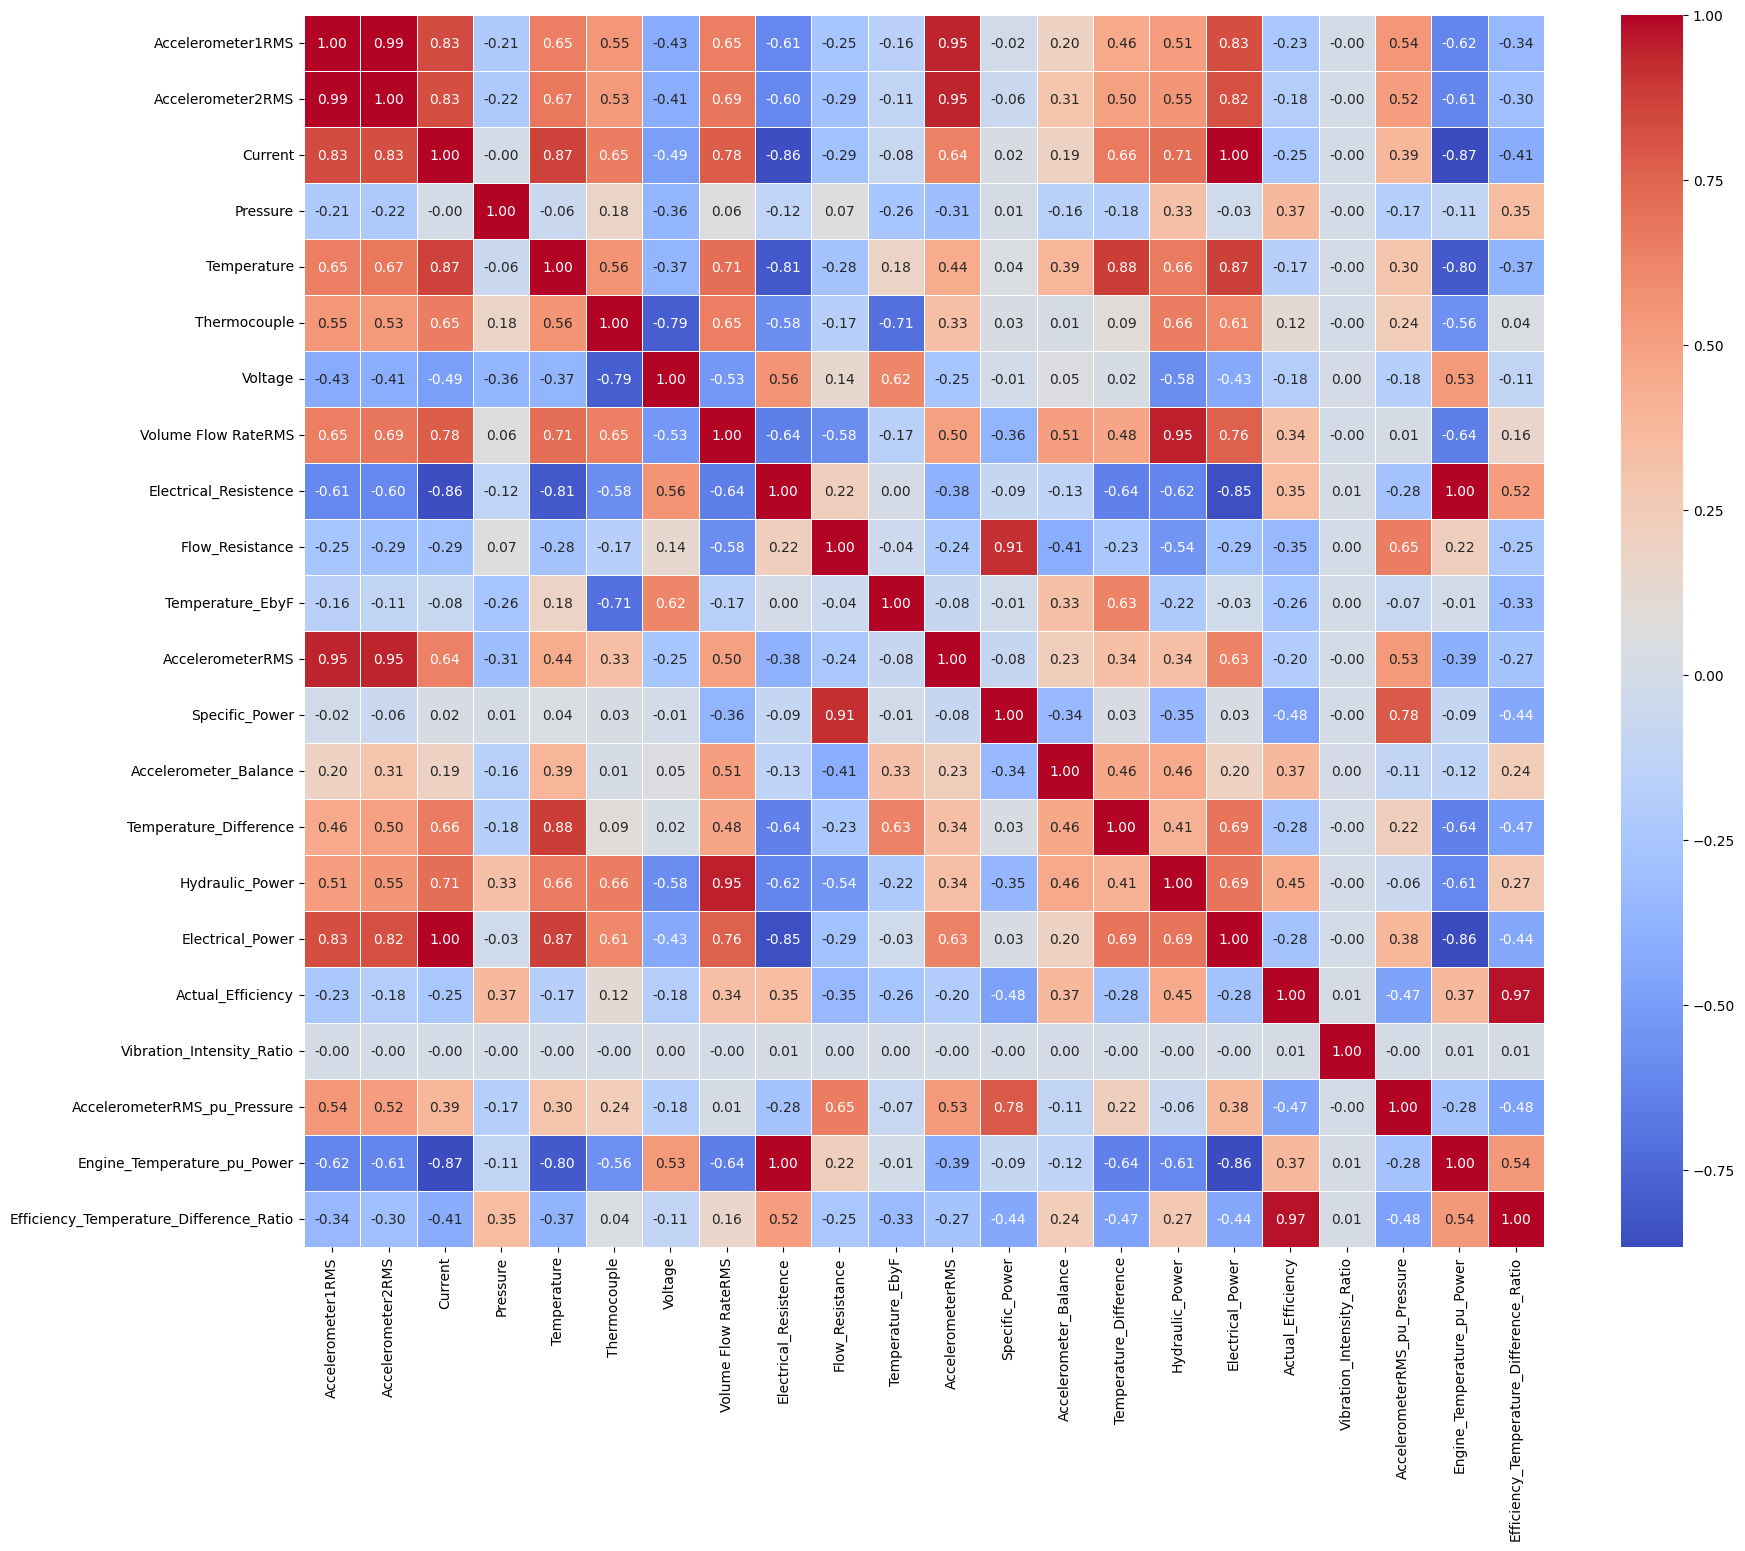

In [38]:
plt.figure(figsize=(20, 16), dpi=PLOT_DPI)

sns.heatmap(tmp_dataframe[tmp_dataframe.columns[:-2]].corr(), annot=True, fmt='.2f', linewidths=.7, cmap="coolwarm")

plt.show()

In [39]:
tmp_dataframe.to_csv(SAVE_DATA_FILE, index=SAVE_INDEX)

## Appendix

**I. Basic & Statistical Features:**

4.  **Statistical Aggregations (over a rolling window - *if time-series data*):**

      * **Mean/Median:** Smoothed average of a parameter over a short period.
      * **Standard Deviation/Variance:** Measures the variability or "noisiness" of a parameter. An increase in vibration standard deviation could signal an issue.
      * **Min/Max:** Extreme values within a window.
      * **Range (Max - Min):** The spread of values within a window.
      * **Skewness:** Measures the asymmetry of the data distribution.
      * **Kurtosis:** Measures the "tailedness" of the data distribution.

**II. Time-Series Specific Features (Assuming your data has a time component or is ordered):**

1.  **Lag Features:**

      * **`Current_t-1`, `Pressure_t-5`:** Values of a parameter from previous time steps. This helps models understand temporal dependencies. For example, current at time `t` might predict current at `t+1` unless an anomaly occurs.

2.  **Windowed Features (as mentioned above but emphasizing time windows):**

      * The statistical aggregations (mean, std dev, min, max, range, skew, kurtosis) are most powerful when applied over sliding time windows (e.g., 5-minute window, 1-hour window). This helps capture short-term vs. long-term behavior.

3.  **Frequency Domain Features (if data sampling rate is high enough to capture waveforms):**

      * **Fast Fourier Transform (FFT) on Accelerometer data:** Decompose vibration signals into their constituent frequencies. Anomalies often manifest as specific frequency peaks or changes in the power spectrum (e.g., bearing faults, looseness).
          * **Spectral Power:** Total energy in specific frequency bands.
          * **Peak Frequencies:** Dominant frequencies.
          * **Band-limited RMS:** RMS calculated for specific frequency bands.
      * This is more advanced and requires sufficient data points within each time window to perform a meaningful FFT.

**Choosing the Right Features and Model:**

  * **Anomaly Detection:**
      * **Unsupervised:** One-Class SVM, Isolation Forest, Local Outlier Factor (LOF), Autoencoders. These models learn the "normal" behavior from your engineered features and identify deviations.
      * **Supervised (if you have enough labeled anomalies):** Standard classification algorithms (Logistic Regression, SVM, Random Forest, Gradient Boosting) can be used, treating anomaly detection as a binary classification problem. However, anomaly datasets are often highly imbalanced, requiring special handling (SMOTE, specific loss functions, threshold tuning).
  * **Feature Importance:** After training, analyze feature importances (e.g., from tree-based models like Random Forest or LightGBM) to understand which engineered features are most indicative of anomalies.

**Important Considerations:**

  * **Data Resolution/Frequency:** The effectiveness of rolling window and lag features heavily depends on your data's sampling rate. Choose window sizes (`window_size` in the example) that make sense for the temporal scale of your anomalies.
  * **Missing Values:** Be mindful of how you handle missing values, especially those introduced by `shift()` or `rolling()`. `fillna()` methods are shown in the example.
  * **Overfitting:** Creating too many highly correlated features can lead to overfitting. Use techniques like Variance Inflation Factor (VIF) to check for multicollinearity, or apply dimensionality reduction (PCA) on the engineered features.
  * **Domain Knowledge:** Always incorporate any specific knowledge you have about pump failures. For instance, if you know a particular vibration frequency indicates a specific bearing fault, prioritize features that capture that.
  * **Validation:** Rigorously validate your feature engineering by testing the performance of your anomaly detection/classification models on unseen data.

With the following sensor parameters, suggest statistical tests that can be performed and what can be infered from these tests.
    1) Accelerometer1RMS - Shows a vibration acceleration (Amount of g units)
    2) Accelerometer2RMS - Shows a vibration acceleration (Amount of g units)
    3) Current - Shows the amperage on the electric motor (Ampere)
    4) Pressure - Represents the pressure in the loop after the water pump (Bar)
    5) Temperature - Shows the temperature of the engine body (The degree Celsius)
    6) Thermocouple - Represents the temperature of the fluid in the circulation loop (The degree Celsius)
    7) Voltage - Shows the voltage on the electric motor (Volt)
    8) RateRMS - Represents the circulation flow rate of the fluid inside the loop (Liter per minute)
    9) anomaly - Shows if the point is anomalous (0 or 1)